In [1]:
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 10
K = K1 = K2 = 3

U = np.random.normal(0, np.sqrt(0.005), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.005), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)


def get_logit(X):
    # Assuming X is already the linear predictor
    return 1 / (1 + np.exp(-X))


def plot_matrix(mat):
    import matplotlib.pyplot as plt

    plt.imshow(mat, aspect="auto", cmap="viridis")
    plt.colorbar()
    plt.show()


Pr = get_logit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

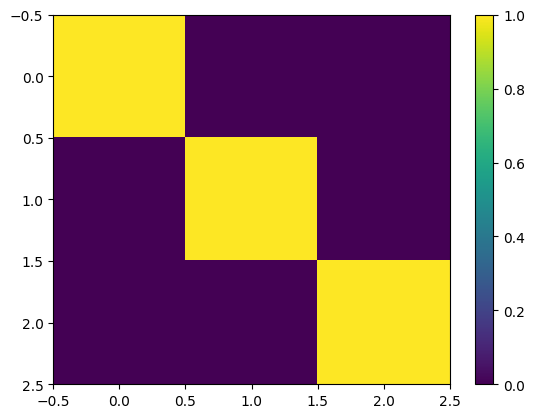

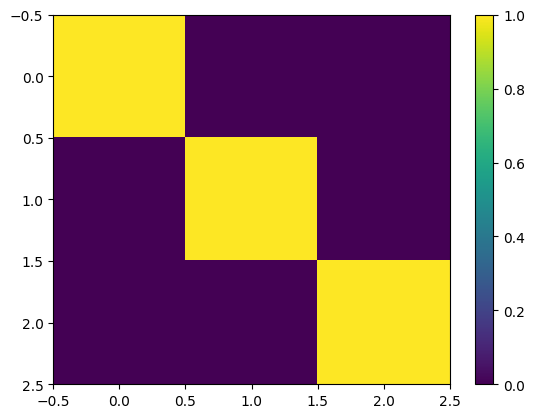

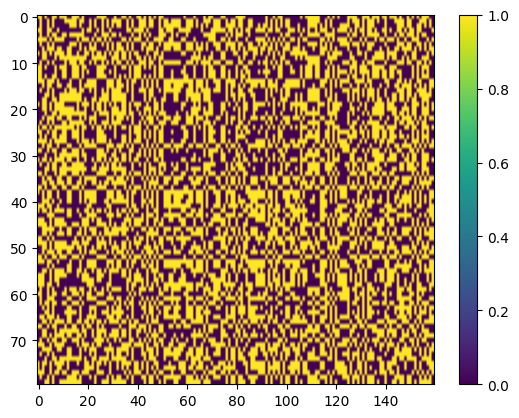

In [9]:
plot_matrix(A_true)
plot_matrix(B_true)
plot_matrix(Y_true)

In [12]:
est_mu, estA, estB = BiSSGL.optimization(
    Y,
    U=U,
    V=V,
    xi=10,
    eta=1e-4,
    tilde_lambda0=5,
    tilde_lambda1=1,
    tilde_alpha=0.5,
    tilde_beta=1,
    lambda0=5,
    lambda1=1,
    alpha=0.5,
    beta=1,
    K=5,
    max_iter=1000,
    tol=1e-5,
)

[-8.29730441 -8.29555912 -2.06758018 -8.29397537 -2.76866259 -8.29328357
 -8.29473994 -8.29320172 -2.06721779 -8.29230871 -2.7648853  -2.76780116
 -2.06862802 -2.76455706 -2.06780643 -2.76500889 -2.06600439 -2.76775007
 -8.2961038  -2.76654106 -8.29784439 -2.7668047  -8.2938675  -8.2945817
 -8.29784842 -2.76645813 -8.29341752 -8.29238762 -2.76306476 -8.29141574
 -2.06671132 -2.76814192 -8.29212749 -2.06445231 -8.29203814 -2.76702678
 -8.29655748 -2.76454307 -2.0636382  -2.76818364 -2.76695985 -2.76967998
 -8.29709055 -2.06575729 -2.76772773 -8.29209872 -1.65626893 -2.06477223
 -2.06618177 -2.06827691 -2.06594166 -8.29516878 -8.29548509 -2.76660662
 -8.29617494 -8.29544871 -8.2934571  -2.06596689 -8.29492103 -2.76572342
 -8.29457598 -8.29261542 -2.76675326 -2.76538165 -2.76506628 -8.29607008
 -8.29476588 -8.29616911 -8.29405133 -8.2949917  -8.29623452 -2.76425757
 -2.06505833 -2.76523457 -2.76210022 -8.29335072 -8.29606688 -2.76792159
 -2.76595152 -8.29475601]


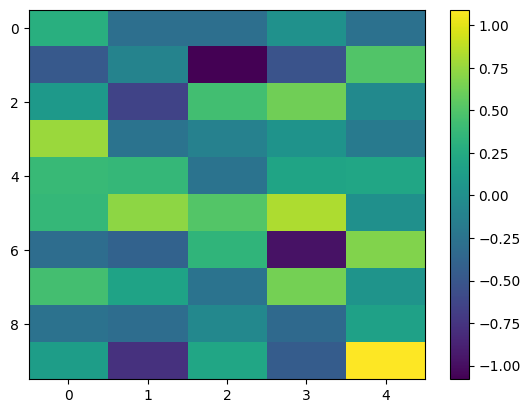

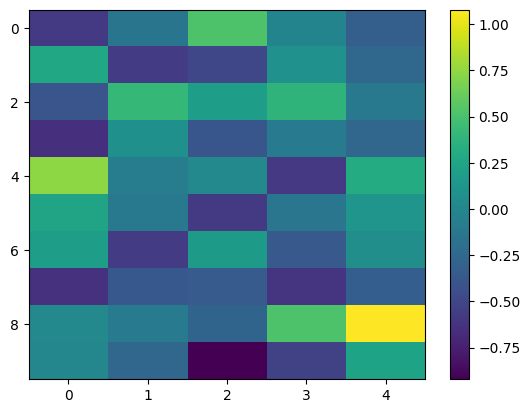

In [13]:
print(est_mu)
plot_matrix(estA)
plot_matrix(estB)

In [ ]:
linalg.norm([1, 2]) ** 2

np.float64(5.000000000000001)